<a href="https://colab.research.google.com/github/Rshamhmd863/Titanic-ML-Project/blob/main/iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the required libraries for data analysis and preprocessing


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Loading the dataset into a pandas DataFrame

In [ ]:
df=pd.read_csv("1) iris.csv")

# Displaying the first few rows of the dataset

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Checking dataset information such as data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df.shape

(150, 5)

# Generating statistical summary for numerical columns

In [ ]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Checking missing values in each column

In [ ]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


# Checking for duplicate rows in the dataset

In [ ]:
df.duplicated().sum()

np.int64(3)

# Removing duplicate

In [ ]:
df.drop_duplicates(inplace=True)

# Check if the dataset is balanced


In [ ]:
print(df["species"].value_counts())

species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64


# Visualize class distribution

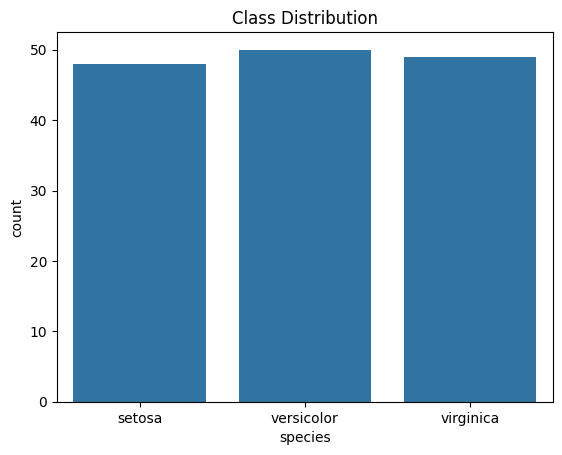

In [ ]:
sns.countplot(x="species", data=df)
plt.title("Class Distribution")
plt.show()

# Detect outliers using Boxplot

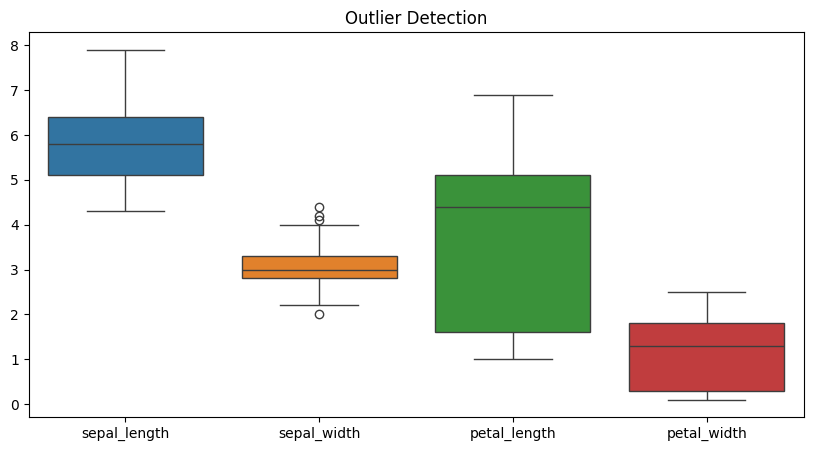

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.drop("species", axis=1))
plt.title("Outlier Detection")
plt.show()

# Detect outliers using IQR

In [ ]:
Q1 = df.drop("species", axis=1).quantile(0.25)
Q3 = df.drop("species", axis=1).quantile(0.75)
IQR = Q3 - Q1
outliers = ((df.drop("species", axis=1) < (Q1 - 1.5 * IQR)) |
            (df.drop("species", axis=1) > (Q3 + 1.5 * IQR)))
print(outliers.sum())

sepal_length    0
sepal_width     4
petal_length    0
petal_width     0
dtype: int64


# Fill missing values in the target column

In [ ]:
df["species"]=df['species'].fillna(df['species'].mode()[0])

# Encode categorical labels into numerical values

In [ ]:
le=LabelEncoder()
df["species"] = le.fit_transform(df["species"])

# Selecting the most relevant features for

In [ ]:
X = df.drop("species", axis=1)
y = df["species"]

# Splitting the dataset into training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#KNN Algorithm



In [ ]:
# Create a KNN classifier with K = 5
knn = KNeighborsClassifier(n_neighbors=5)
# Train the model using the training data
knn.fit(X_train, y_train)
# Predict the target values for the test set
y_pred = knn.predict(X_test)

# Evaluate Model Accuracy

In [ ]:
# Calculate the classification accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", accuracy * 100)

Accuracy = 93.33333333333333


# Generate Confusion Matrix

In [ ]:
# Display the confusion matrix to evaluate
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]


# Display Precision
for each class

In [ ]:
precision = precision_score(y_test, y_pred, average='macro')
print(f"Precision (Macro): {(precision)*100:.2f}")

Precision (Macro): 92.96


# Display Recall
for each class

In [ ]:
recall = recall_score(y_test, y_pred, average='macro')
print(f"Recall (Macro): {(recall)*100:.2f}")

Recall (Macro): 92.96


# Compare Different K Values

In [ ]:
#Test multiple values of K and compare accuracy
results = []
for k in [1,3,5,7,9,11]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test,pred)
    results.append([k,(acc)*100])

# Display Comparison Results

In [ ]:
# Create a DataFrame to summarize the results
comparison = pd.DataFrame(
    results,
    columns=["K Value","Accuracy"]
)
print(comparison)

   K Value   Accuracy
0        1  93.333333
1        3  93.333333
2        5  93.333333
3        7  93.333333
4        9  90.000000
5       11  90.000000


# Visualizing For accurcy in k

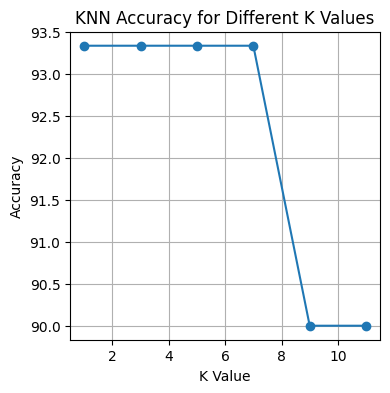

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(comparison["K Value"],comparison["Accuracy"],marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.grid(True)
plt.show()

#Level 2 TASK1

In [ ]:
# Initialize the Decision Tree classifier with a fixed random state for reproducibility
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
# Train the model using the training dataset
dt.fit(X_train,y_train)
# Generate predictions on the test dataset
y_pred = dt.predict(X_test)
# Calculate and display the model accuracy
print("Accuracy=",(accuracy_score(y_test,y_pred))*100)
# Import F1-score evaluation metric
from sklearn.metrics import f1_score
# Calculate and display the weighted F1-score
print("F1_score=",(f1_score(y_test,y_pred,average="weighted"))*100)

Accuracy= 93.33333333333333
F1_score= 93.33333333333333


# visualization

In [ ]:
# Initialize a pruned Decision Tree with a maximum depth of 3
pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the pruned model on the training dataset
pruned_tree.fit(X_train, y_train)

# Generate predictions using the pruned model
y_pred_pruned = pruned_tree.predict(X_test)

# Calculate and display the model accuracy
print("Accuracy =", accuracy_score(y_test, y_pred_pruned) * 100)

# Calculate and display the weighted F1-score
print("F1_score =", f1_score(y_test, y_pred_pruned, average="weighted") * 100)

Accuracy = 90.0
F1_score = 89.9439775910364


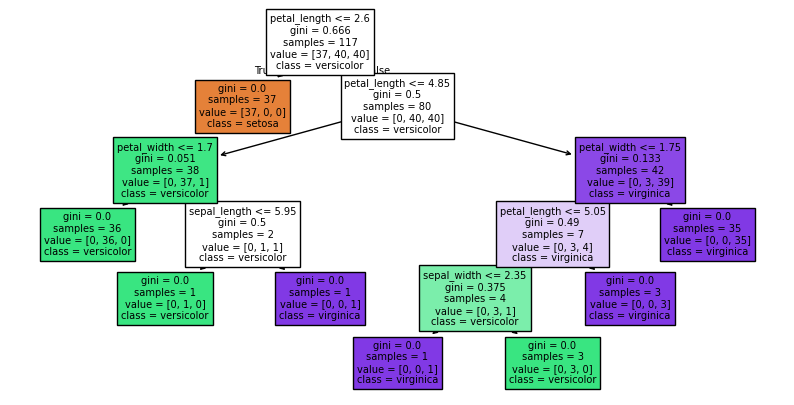

In [ ]:
# Create a figure with a larger size for better visualization
plt.figure(figsize=(10,5))
# Visualize the trained Decision Tree model
tree.plot_tree(dt,feature_names=df.columns[:-1],class_names=["setosa","versicolor","virginica"],filled=True)
# Display the tree plot
plt.show()

In [ ]:
# Initialize the StandardScaler object
scaler = StandardScaler()

# Apply feature scaling to all input features while excluding the target column
X_scaled = scaler.fit_transform(df.drop("species", axis=1))

# Level2 task2

In [ ]:
# Create an empty list to store WCSS values for different numbers of clusters
wcss = []
# Train K-Means models with cluster numbers ranging from 1 to 10
for i in range(1, 11):
    # Initialize the K-Means model
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    # Fit the model on the scaled dataset
    kmeans.fit(X_scaled)
    # Store the Within-Cluster Sum of Squares (WCSS)
    wcss.append(kmeans.inertia_)

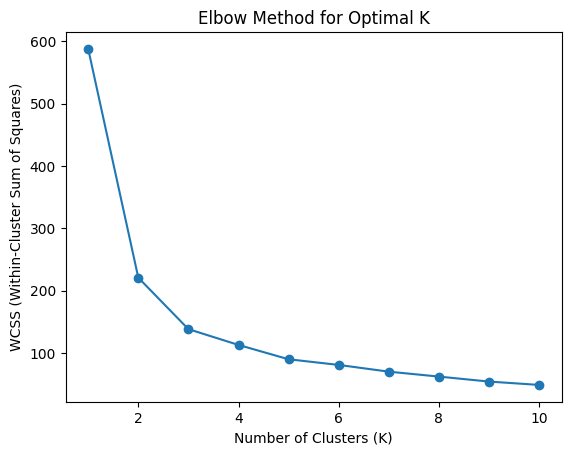

In [ ]:
# Plot the Elbow Method curve (WCSS vs Number of Clusters)
plt.plot(range(1, 11), wcss, marker="o")
# Label the axes
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
# Add a title to the plot
plt.title("Elbow Method for Optimal K")
# Display the plot
plt.show()

In [ ]:
# Initialize the K-Means model with the chosen number of clusters (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model and assign each data point to a cluster
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels as a new column in the original DataFrame
df["Cluster"] = clusters

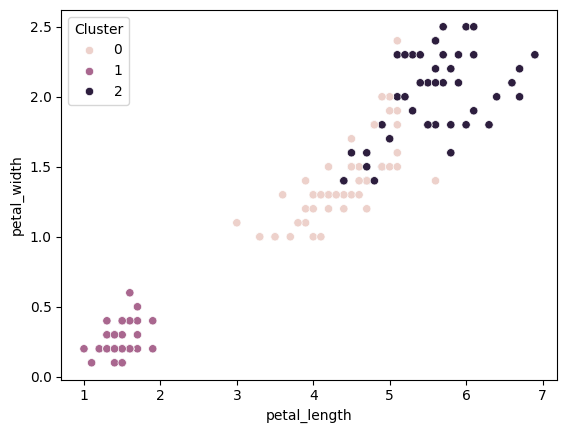

In [ ]:
# Visualize the clustering results using a scatter plot
sns.scatterplot(
    x=df["petal_length"],   # X-axis: petal length
    y=df["petal_width"],    # Y-axis: petal width
    hue=df["Cluster"]       # Color points based on assigned cluster
)

# Display the plot
plt.show()

# Level3 task1

In [ ]:
# Initialize the Random Forest classifier with 100 trees
rf = RandomForestClassifier(
    n_estimators=100,   # Number of decision trees in the forest
    max_depth=5,        # Maximum depth of each tree to reduce overfitting
    random_state=42     # Ensures reproducibility of results
)

# Train the model on the training dataset
rf.fit(X_train, y_train)

# Make predictions on the test dataset
y_pred = rf.predict(X_test)
# Calculate and display model accuracy
print("Accuracy =", accuracy_score(y_test, y_pred) * 100)

# Import F1-score metric
from sklearn.metrics import f1_score

# Calculate and display weighted F1-score
print("F1_score =", f1_score(y_test, y_pred, average="weighted") * 100)

Accuracy = 93.33333333333333
F1_score = 93.33333333333333


In [ ]:
# Generate a detailed classification report including precision, recall, and F1-score
from sklearn.metrics import classification_report

# Print evaluation metrics for each class
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



# Level3 Task2

In [ ]:
# Perform 5-fold cross-validation on the Random Forest model
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

# Print accuracy scores for each fold
print(scores)

# Print the average cross-validation accuracy
print(scores.mean())

[0.96666667 0.96666667 0.93103448 0.93103448 1.        ]
0.9590804597701149


In [ ]:
# Initialize a Support Vector Machine with a linear kernel
svm_linear = SVC(kernel="linear", probability=True)

# Train the model on the training dataset
svm_linear.fit(X_train, y_train)

# Make predictions on the test dataset
pred_linear = svm_linear.predict(X_test)

In [ ]:
# Initialize a Support Vector Machine with RBF (non-linear) kernel
svm_rbf = SVC(kernel="rbf", probability=True)

# Train the model on the training dataset
svm_rbf.fit(X_train, y_train)

# Make predictions on the test dataset
pred_rbf = svm_rbf.predict(X_test)

In [ ]:
# Calculate and print accuracy for Linear SVM
print("SVM_Linear =", accuracy_score(y_test, pred_linear) * 100)

# Calculate and print accuracy for RBF SVM
print("Accuracy_rbf =", accuracy_score(y_test, pred_rbf) * 100)

SVM_Linear = 96.66666666666667
Accuracy_rbf = 93.33333333333333


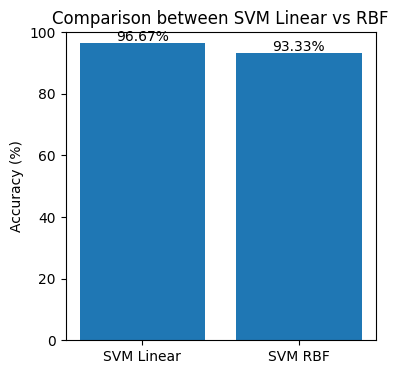

In [ ]:
# accuracies
linear_acc = accuracy_score(y_test, pred_linear) * 100
rbf_acc = accuracy_score(y_test, pred_rbf) * 100

# labels and values
models = ["SVM Linear", "SVM RBF"]
accuracies = [linear_acc, rbf_acc]

# plot
plt.figure(figsize=(4,4))
plt.bar(models, accuracies)

# labels
plt.ylabel("Accuracy (%)")
plt.title("Comparison between SVM Linear vs RBF")

# show values on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.ylim(0, 100)
plt.show()